<a href="https://colab.research.google.com/github/MarioHervas/pytorch-tutorial/blob/main/pytorch_first_steps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt


## Data preparation

1. Get data into numbers
2. Get model to learn patterns between the numbers

Linear regression formula with known parameters

Y = a + bX

In [2]:
#Known parameters
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]
#len(X), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

##Splitting data into training and test sets
Works like this - Training set --> Validation Set --> Test set

Training 60-80
Validation 10-20
Testing set 10-20

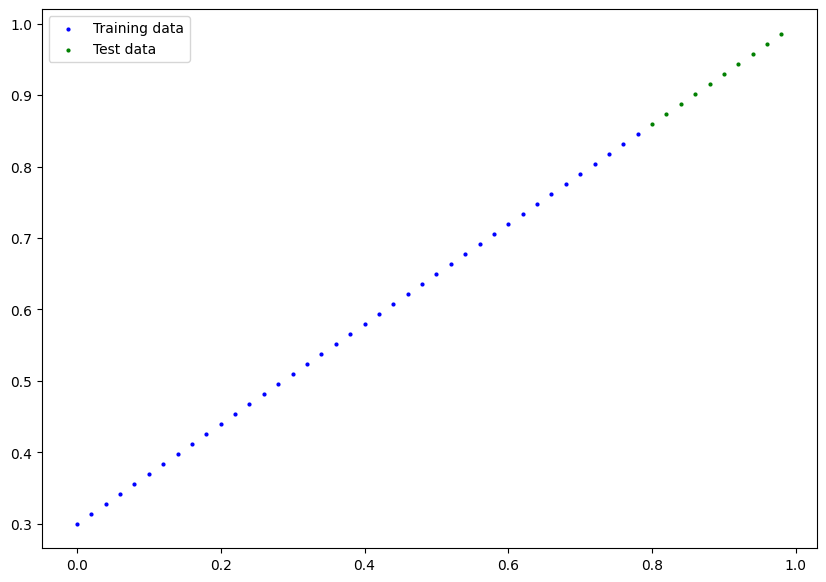

In [3]:
train_split = int(0.8*len(X))
X_train,y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:],y[train_split:]

len(X_train),len(X_test)

def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = None):
  plt.figure(figsize =(10,7))

  plt.scatter(train_data,train_labels,c="b",s=4,label ="Training data")

  plt.scatter(test_data,test_labels,c="g",s=4,label="Test data")

  if predictions is not None:
    plt.scatter(test_data,predictions,c="r",s=4,label="Pred")
  plt.legend()

plot_predictions()





The model starts with random values (weight & bias).It looks at the data to adjust the correct values for achieving the straight line.

Two algos:

1. Gradient Descent
2. Backpropagation

In [4]:
#Model for the function

class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad = True,
                                            dtype = torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad = True,
                                         dtype=torch.float))

  def forward(self, x: torch.Tensor) -> torch.Tensor:
      return self.weights * x + self.bias


### PyTorch building essentials

* torch.nn - contains building for computational graphs
* torch.nn.Parameter - what the model should learn
* torch.nn.Module - Base class for the models, override forward()
* torch.optim -optimizers, they help with gradient descent


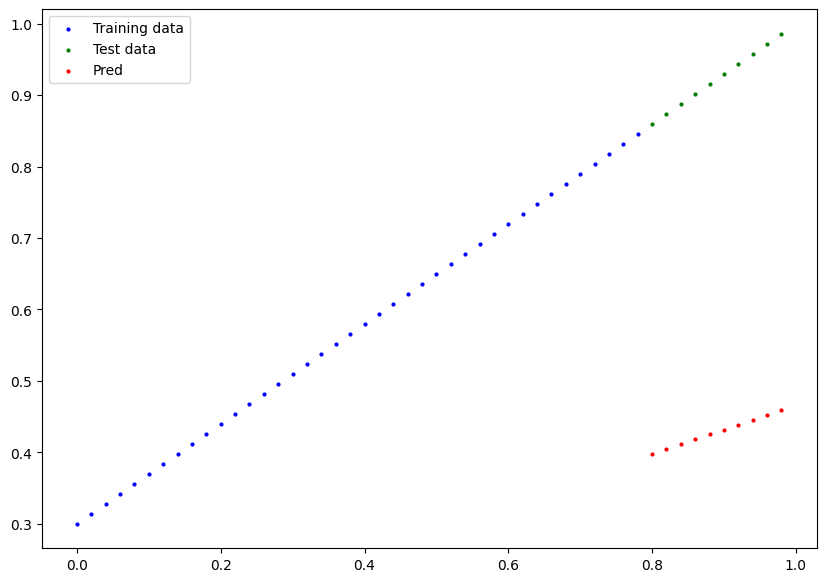

In [5]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

list(model_0.parameters())

model_0.state_dict()

with torch.inference_mode():
  y_preds = model_0(X_test)
plot_predictions(predictions = y_preds)

### Creating a loss function and optimizer in PyTorch
For our model to update its parameters on its own, we'll need to add a few more things to our recipe.

And that's a **loss function** as well as an **optimizer**.

The rolls of these are:

| Function | What does it do? | Where does it live in PyTorch? | Common values |
| ----- | ----- | ----- | ----- |
| **Loss function** | Measures how wrong your model's predictions (e.g. `y_preds`) are compared to the truth labels (e.g. `y_test`). Lower the better. | PyTorch has plenty of built-in loss functions in [`torch.nn`](https://pytorch.org/docs/stable/nn.html#loss-functions). | Mean absolute error (MAE) for regression problems ([`torch.nn.L1Loss()`](https://pytorch.org/docs/stable/generated/torch.nn.L1Loss.html)). Binary cross entropy for binary classification problems ([`torch.nn.BCELoss()`](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html)).  |
| **Optimizer** | Tells your model how to update its internal parameters to best lower the loss. | You can find various optimization function implementations in [`torch.optim`](https://pytorch.org/docs/stable/optim.html). | Stochastic gradient descent ([`torch.optim.SGD()`](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html#torch.optim.SGD)). Adam optimizer ([`torch.optim.Adam()`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html#torch.optim.Adam)). |

Let's create a loss function and an optimizer we can use to help improve our model.

Depending on what kind of problem you're working on will depend on what loss function and what optimizer you use.

However, there are some common values, that are known to work well such as the SGD (stochastic gradient descent) or Adam optimizer. And the MAE (mean absolute error) loss function for regression problems (predicting a number) or binary cross entropy loss function for classification problems (predicting one thing or another).

For our problem, since we're predicting a number, let's use MAE (which is under `torch.nn.L1Loss()`) in PyTorch as our loss function.

![what MAE loss looks like for our plot data](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-mae-loss-annotated.png)
*Mean absolute error (MAE, in PyTorch: `torch.nn.L1Loss`) measures the absolute difference between two points (predictions and labels) and then takes the mean across all examples.*

And we'll use SGD, `torch.optim.SGD(params, lr)` where:

* `params` is the target model parameters you'd like to optimize (e.g. the `weights` and `bias` values we randomly set before).
* `lr` is the **learning rate** you'd like the optimizer to update the parameters at, higher means the optimizer will try larger updates (these can sometimes be too large and the optimizer will fail to work), lower means the optimizer will try smaller updates (these can sometimes be too small and the optimizer will take too long to find the ideal values). The learning rate is considered a **hyperparameter** (because it's set by a machine learning engineer). Common starting values for the learning rate are `0.01`, `0.001`, `0.0001`, however, these can also be adjusted over time (this is called [learning rate scheduling](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate)).


In [6]:
#Set up a loss function

loss_fn = nn.L1Loss()

#Set up an optimizer
optimizer = torch.optim.SGD(model_0.parameters(),
                            lr=0.01)


### Builiding a training and test loop in Pytorch

We need:

0. Loop through the data
1. Foward pass (this involves data moving through our forward functions)
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calcultae the gradients of each the parameters of our model in respect to our loss function (**backpropagation**)
5. Optimizer step -


In [7]:
#Training and testing loop
epochs = 200 #One loop through the data
epoch_count= []
loss_values = []
test_loss_values = []

#0. Loop through the data

for epoch in range (epochs):
  model_0.train() #Set model to train mode, sets all parameters that require gradients to require gradients
  # 1. Forward pass
  y_pred = model_0(X_train)
  # 2. Calculate the loss
  loss = loss_fn(y_pred,y_train)

  # 3 - Optimizer zero grad
  optimizer.zero_grad()
  # 4 - Perform backpropagation on the loss with respect to the params of the model
  loss.backward()
  # 5 - Step the optimizer
  optimizer.step()
  #Testing
  model_0.eval()
  with torch.inference_mode():
    # 1 Forarwd path
    test_pred = model_0(X_test)
    # 2. Calculate the loss with never seen data by model
    test_loss = loss_fn(test_pred,y_test)

  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch: {epoch} | Loss: {loss} | test loss:{test_loss}" )


model_0.state_dict()

Epoch: 0 | Loss: 0.31288138031959534 | test loss:0.48106518387794495
Epoch: 10 | Loss: 0.1976713240146637 | test loss:0.3463551998138428
Epoch: 20 | Loss: 0.08908725529909134 | test loss:0.21729660034179688
Epoch: 30 | Loss: 0.053148526698350906 | test loss:0.14464017748832703
Epoch: 40 | Loss: 0.04543796554207802 | test loss:0.11360953003168106
Epoch: 50 | Loss: 0.04167863354086876 | test loss:0.09919948130846024
Epoch: 60 | Loss: 0.03818932920694351 | test loss:0.08886633068323135
Epoch: 70 | Loss: 0.03476089984178543 | test loss:0.0805937647819519
Epoch: 80 | Loss: 0.03132382780313492 | test loss:0.07232122868299484
Epoch: 90 | Loss: 0.02788739837706089 | test loss:0.06473556160926819
Epoch: 100 | Loss: 0.024458957836031914 | test loss:0.05646304413676262
Epoch: 110 | Loss: 0.021020207554101944 | test loss:0.04819049686193466
Epoch: 120 | Loss: 0.01758546568453312 | test loss:0.04060482233762741
Epoch: 130 | Loss: 0.014155393466353416 | test loss:0.03233227878808975
Epoch: 140 | Los

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

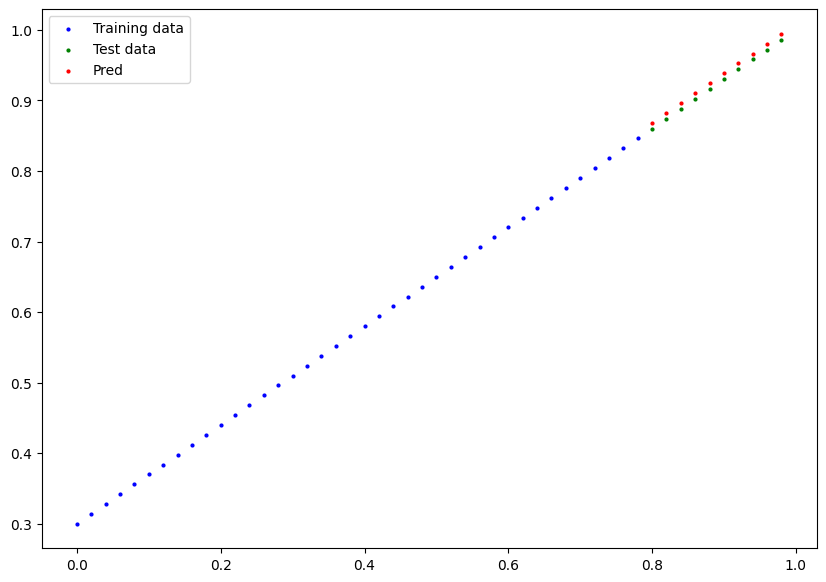

In [8]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)
plot_predictions(predictions=y_preds_new)

/tmp/ipykernel_20745/2034397045.py:3: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.plot(epoch_count,np.array(torch.tensor(loss_values).cpu()),label="Train loss")


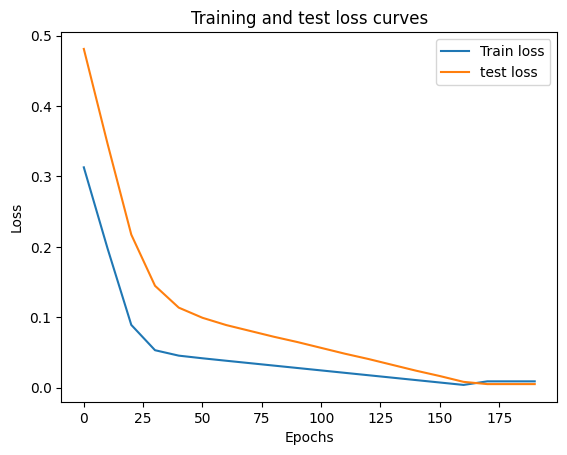

In [9]:
#Fewer steps to refine it.
import numpy as np
plt.plot(epoch_count,np.array(torch.tensor(loss_values).cpu()),label="Train loss")
plt.plot(epoch_count,np.array(torch.tensor(test_loss_values).cpu()),label = "test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()




### Saving the model

1. 'torch.save()' - PyTorch object
2. 'torch.load()' - allows you load a saved PyTorch object
3. torch.nn.Module.load_state_dict()¡ - load a model saved dict


In [10]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok=True)

MODEL_NAME = "pytorch_first_steps.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
MODEL_SAVE_PATH

torch.save(obj=model_0.state_dict(),f=MODEL_SAVE_PATH)

In [11]:
#Loading model by instancing a new model class and insert the state dict

loaded_model_0 = LinearRegressionModel()

loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

loaded_model_0.state_dict()
loaded_model_0.eval()
with torch.inference_mode():
  og_preds = model_0(X_test)

with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

og_preds == loaded_model_preds


tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### 6 Putting everything together



In [13]:
import torch
from torch import nn
import matplotlib.pyplot as plt

weight = 0.4
bias = 0.2

start = 0
end = 1
step = 0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.2000],
         [0.2080],
         [0.2160],
         [0.2240],
         [0.2320],
         [0.2400],
         [0.2480],
         [0.2560],
         [0.2640],
         [0.2720]]))

In [14]:
#Split data
train_split = int(0.8*len(X))
X_train, y_train = X[:train_split],y[:train_split]
X_test, y_test = X[train_split:],y[train_split:]


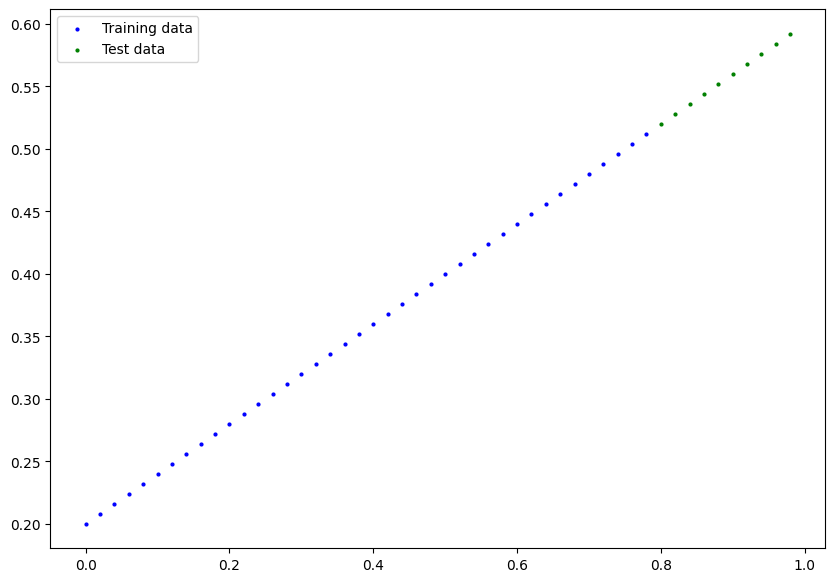

In [15]:
#Plot the data

plot_predictions(X_train,y_train,X_test,y_test)

In [16]:
#Building the linear model

class LinearModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    #Use nn.Linear() for creating params
    self.linear_layer = nn.Linear(in_features=1,out_features=1)
  def forward(self,x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

torch.manual_seed(42)
model_1 = LinearModelV2()
model_1.state_dict()
model_1 = model_1.to(device)


In [17]:
#Training

loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params= model_1.parameters(),lr=0.001)

torch.manual_seed(42)

epochs = 1300

X_train = X_train.to(device)
y_train = y_train.to(device)
model_1 = model_1.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  model_1.train()
  y_pred = model_1(X_train)
  loss = loss_fn(y_pred,y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_1.eval()
  with torch.inference_mode():
    test_pred = model_1(X_test)
    test_loss = loss_fn(test_pred,y_test)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} Loss: {loss} Test Loss: {test_loss}")

Epoch: 0 Loss: 0.7721779346466064 Test Loss: 0.9531000256538391
Epoch: 100 Loss: 0.6569694876670837 Test Loss: 0.8183919787406921
Epoch: 200 Loss: 0.541761040687561 Test Loss: 0.6836838722229004
Epoch: 300 Loss: 0.4265526235103607 Test Loss: 0.5489757657051086
Epoch: 400 Loss: 0.3113441467285156 Test Loss: 0.4142676293849945
Epoch: 500 Loss: 0.19613568484783173 Test Loss: 0.27955958247184753
Epoch: 600 Loss: 0.08092694729566574 Test Loss: 0.14485116302967072
Epoch: 700 Loss: 0.019484760239720345 Test Loss: 0.05244898423552513
Epoch: 800 Loss: 0.015343248844146729 Test Loss: 0.036110665649175644
Epoch: 900 Loss: 0.01190275140106678 Test Loss: 0.0277690589427948
Epoch: 1000 Loss: 0.008468176238238811 Test Loss: 0.019702298566699028
Epoch: 1100 Loss: 0.005034258123487234 Test Loss: 0.011704242788255215
Epoch: 1200 Loss: 0.0015995204448699951 Test Loss: 0.0036374807823449373


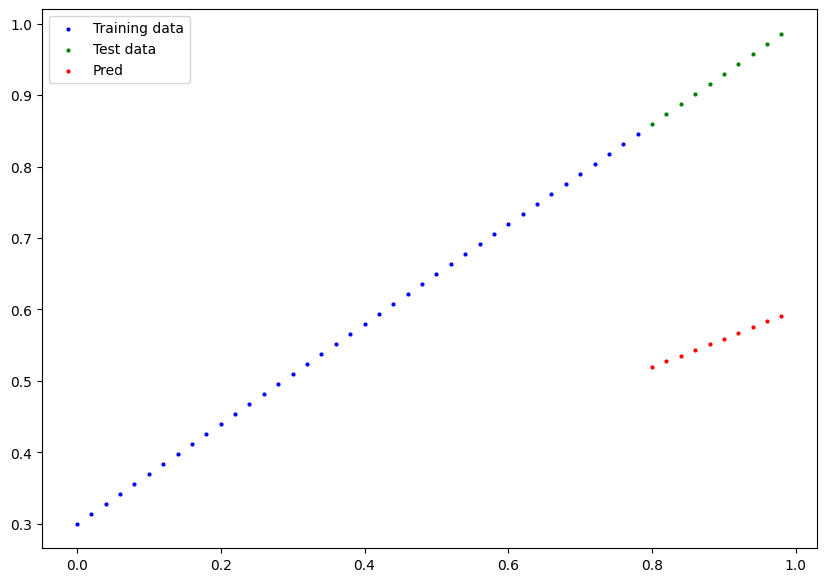

In [18]:
model_1.state_dict()
with torch.inference_mode():
  y_preds = model_1(X_test)
plot_predictions(predictions =y_preds.cpu())

In [19]:
#Saving the new model

from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok=True)

MODEL_NAME = "model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
MODEL_SAVE_PATH

torch.save(obj=model_1.state_dict(),f=MODEL_SAVE_PATH)

loaded_model_1 = LinearModelV2()

loaded_model_1.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

loaded_model_1.state_dict()
loaded_model_1.eval()
with torch.inference_mode():
  og_preds = model_1(X_test)

loaded_model_1.to(device)

with torch.inference_mode():
  loaded_model_preds = loaded_model_1(X_test)

og_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')